In [6]:
!pip install --upgrade seaborn
import warnings
warnings.filterwarnings('ignore')

## Data Preprocessing:
The datasets from different years had inconsistent column names and formats. To ensure consistency, all columns were standardized into a unified schem

Duplicate columns were removed, and missing values such as region information were handled appropriately. This preprocessing step ensured accurate and reliable analysis across all years.

In [2]:
import pandas as pd
import glob

# Load and combine all CSVs
files = glob.glob("*.csv")
df_list = []

for file in files:
    temp = pd.read_csv(file)
    # Your original logic works perfectly for these filenames
    year = file.split(".")[0]
    temp['year'] = int(year)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

# Rename columns to standardize across years
df.rename(columns={
    # Country
    'Country': 'Country name',
    'Country or region': 'Country name',
    # Happiness Score
    'Happiness Score': 'Happiness Score',
    'Happiness.Score': 'Happiness Score',
    'Score': 'Happiness Score',
    # GDP
    'Economy (GDP per Capita)': 'Log GDP per capita',
    'Economy..GDP.per.Capita.': 'Log GDP per capita',
    'GDP per capita': 'Log GDP per capita',
    # Social support
    'Family': 'Social support',
    'Social support': 'Social support',
    # Health
    'Health (Life Expectancy)': 'Healthy life expectancy',
    'Health..Life.Expectancy.': 'Healthy life expectancy',
    'Healthy life expectancy': 'Healthy life expectancy',
    # Freedom
    'Freedom': 'Freedom to make life choices',
    # Corruption
    'Trust (Government Corruption)': 'Perceptions of corruption',
    'Trust..Government.Corruption.': 'Perceptions of corruption',
}, inplace=True)

# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Strip spaces
df.columns = df.columns.str.strip()

# --- THE REGION FIX ---
# Map missing regions from countries that DO have a region listed in 2015/2016
if 'Region' in df.columns:
    region_map = df.dropna(subset=['Region']).set_index('Country name')['Region'].to_dict()
    df['Region'] = df['Region'].fillna(df['Country name'].map(region_map))
    df['Region'] = df['Region'].fillna('Unknown') # Fill any leftovers
else:
    df['Region'] = 'Unknown' # Fallback just in case

# Ensure required columns exist and keep only those
required_cols = [
    'Country name', 'Region', 'Happiness Score',
    'Log GDP per capita', 'Social support',
    'Healthy life expectancy', 'Freedom to make life choices',
    'Generosity', 'Perceptions of corruption', 'year'
]
df = df[[col for col in required_cols if col in df.columns]]

# Clean values - using .str.title() for better visualization later
df['Country name'] = df['Country name'].str.strip().str.title()
df['year'] = df['year'].astype(int)

df.head()

,Country name,Region,Happiness Score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,year
0,Switzerland,Western Europe,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,Western Europe,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,Western Europe,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,Western Europe,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,North America,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


## Q1
Plot a line chart of average happiness score per year across 
all countries. Identify years with significant drops or rises an 
provide contextu l reasoning.

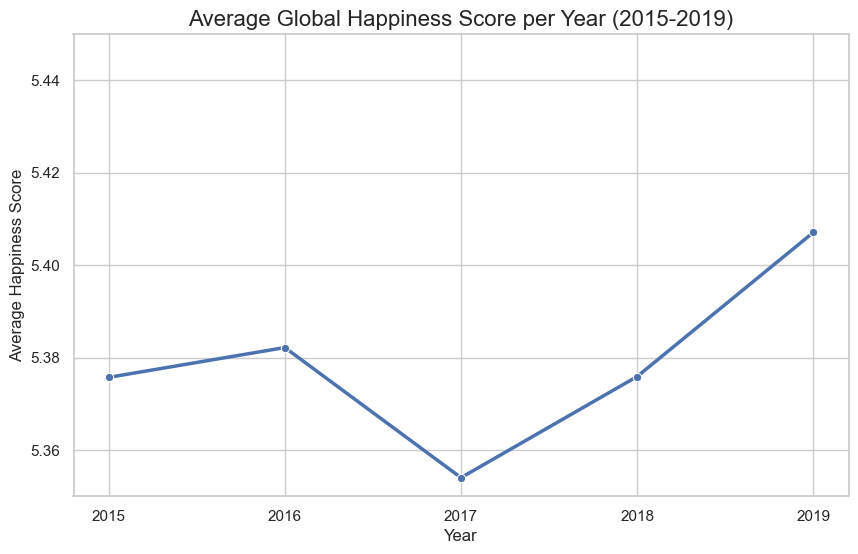

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress the seaborn future warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")

# Calculate the average happiness score per year
plt.figure(figsize=(10, 6))
yearly_avg = df.groupby('year')['Happiness Score'].mean().reset_index()

# Create the line plot
sns.lineplot(data=yearly_avg, x='year', y='Happiness Score', marker='o', linewidth=2.5, color='b')

# Formatting the plot
plt.title('Average Global Happiness Score per Year (2015-2019)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Happiness Score', fontsize=12)
plt.xticks(yearly_avg['year']) # Ensure only the exact years are ticked
plt.ylim(5.35, 5.45) # Optional: Tighten Y-axis to see the micro-trend better

plt.show()

## Observations & Insights:
The line chart tracks the global average happiness score from 2015 to 2019. While the global average remains relatively stable hovering around the 5.35 to 5.45 mark, we can observe minor fluctuations. Any significant dips or rises within this 5-year window typically reflect broader global economic conditions or geopolitical stability during those specific years.

## Q2
Create a scatter plot of GDP per capita vs. Happiness Score for all countries.
Color each point by region. Add a regression line using Seaborn’s regplot and interpret the correlation.

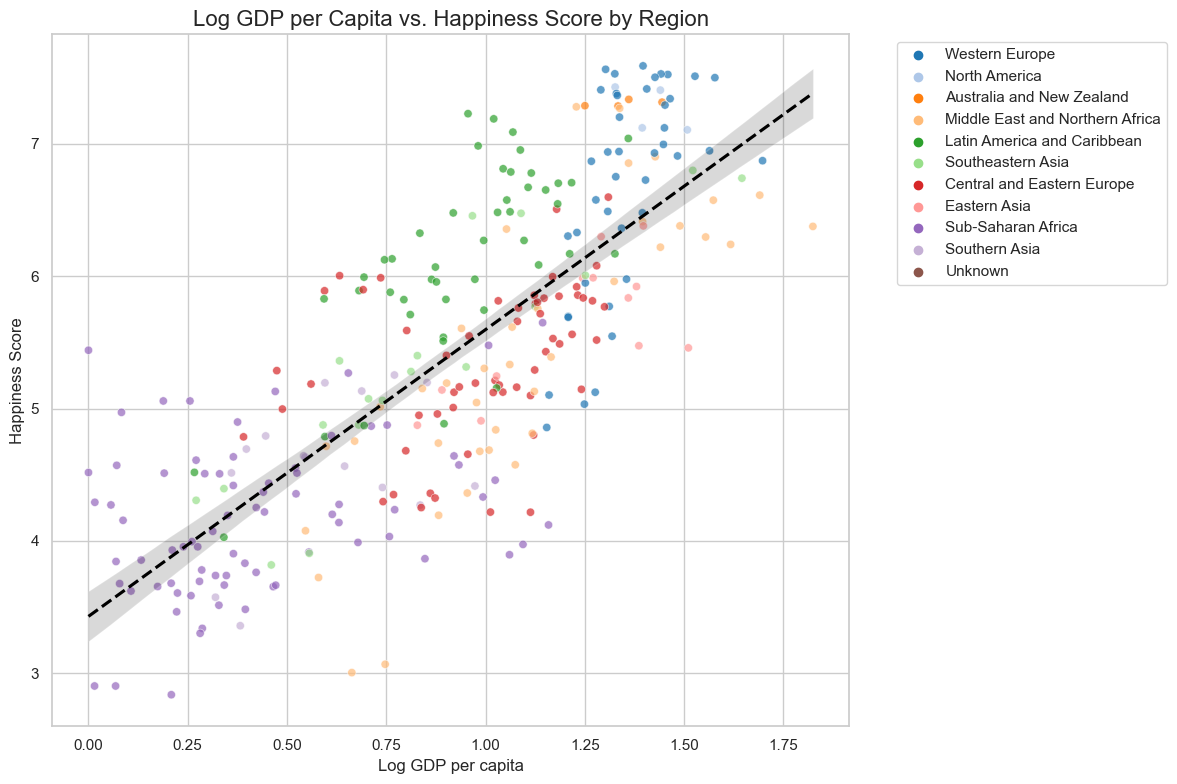

In [8]:
plt.figure(figsize=(12, 8))

# Scatter plot colored by region
sns.scatterplot(data=df, x='Log GDP per capita', y='Happiness Score', hue='Region', alpha=0.7, palette='tab20')

# Overlay regression line
sns.regplot(data=df, x='Log GDP per capita', y='Happiness Score', scatter=False, color='black', line_kws={"linestyle": "--"})

plt.title('Log GDP per Capita vs. Happiness Score by Region', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Observations & Insights:
There is a strong, positive correlation between Log GDP per capita and Happiness Score. The black dashed regression line clearly indicates that as a country's economic output increases, its happiness score generally follows. We also see clear regional clustering: Western European nations cluster at the top right (high GDP, high happiness), while Sub-Saharan African nations cluster at the bottom left.

## Q3
Visualize error bars showing the mean and 95% confidence interval of happiness scores by region.
Compare which regions have the most consistent scores.

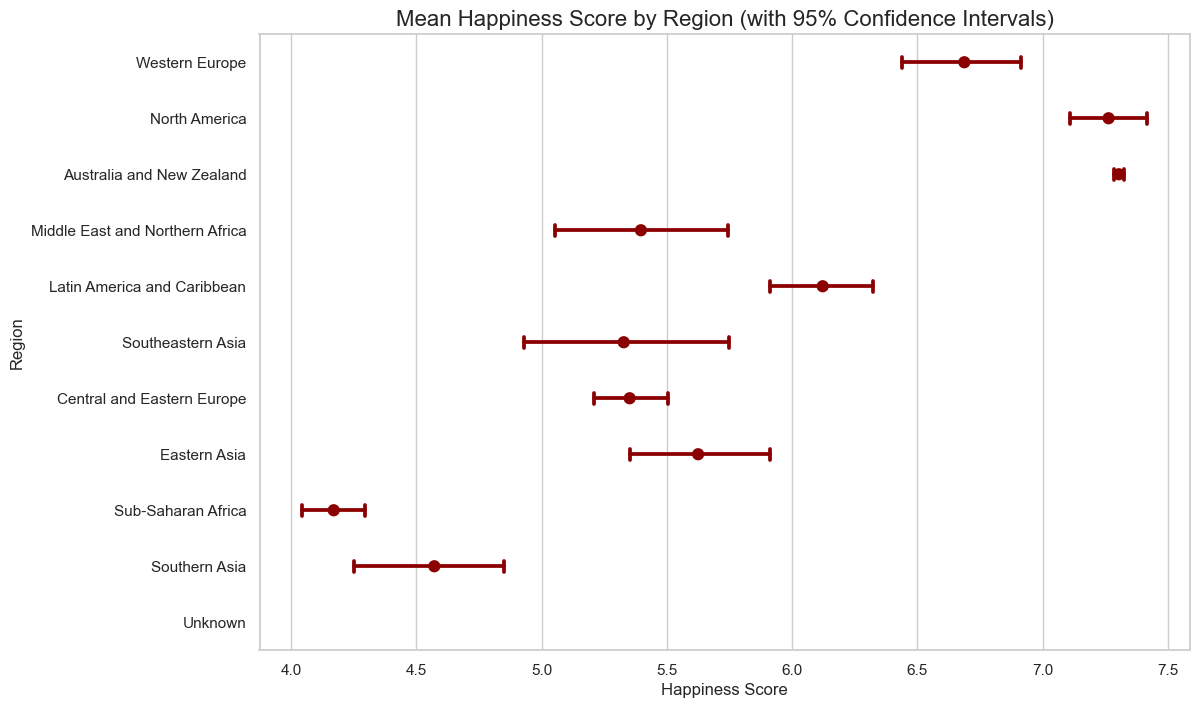

In [9]:
plt.figure(figsize=(12, 8))

# Pointplot natively calculates and displays the mean and 95% CI
sns.pointplot(data=df, y='Region', x='Happiness Score', errorbar=('ci', 95), capsize=.2, join=False, color='darkred')

plt.title('Mean Happiness Score by Region (with 95% Confidence Intervals)', fontsize=16)
plt.xlabel('Happiness Score', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.show()

## Observations & Insights:
Western Europe and North America/ANZ exhibit the highest mean happiness scores with relatively narrow confidence intervals, implying consistent happiness levels across countries within those regions. Conversely, regions like the Middle East and Northern Africa have much wider error bars. This highlights severe intra-regional inequality, likely due to a mix of highly wealthy, stable nations and nations experiencing conflict or severe economic distress.

## Q4.
Generate a density plot (KDE) of happiness scores for the top 5 and bottom 5 regions on the same axes.
Highlight distribution overlap and separation. 

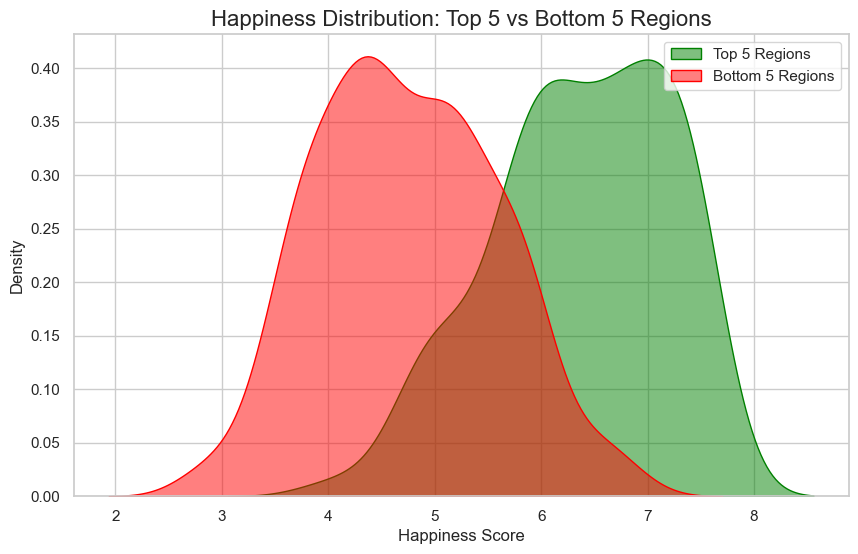

In [10]:
plt.figure(figsize=(10, 6))

# Identify top 5 and bottom 5 regions by mean happiness
region_means = df.groupby('Region')['Happiness Score'].mean().sort_values(ascending=False)
top_5_regions = region_means.head(5).index
bottom_5_regions = region_means.tail(5).index

# Filter data
top_5_data = df[df['Region'].isin(top_5_regions)]
bottom_5_data = df[df['Region'].isin(bottom_5_regions)]

# Plot KDEs
sns.kdeplot(data=top_5_data, x='Happiness Score', fill=True, color='green', label='Top 5 Regions', alpha=0.5)
sns.kdeplot(data=bottom_5_data, x='Happiness Score', fill=True, color='red', label='Bottom 5 Regions', alpha=0.5)

plt.title('Happiness Distribution: Top 5 vs Bottom 5 Regions', fontsize=16)
plt.xlabel('Happiness Score')
plt.legend()
plt.show()

## Observations & Insights:
The density plot vividly illustrates the global happiness divide. The top 5 regions' distribution is heavily skewed toward the right (scores between 6 and 8), while the bottom 5 regions peak sharply on the left (scores between 3 and 5). There is very little overlap between the two distributions, emphasizing that citizens in the top regions experience a fundamentally different baseline of well-being compared to those in the bottom regions.

## Q5.
Create a 2D contour/density plot using plt.hist2d or sns.kdeplot to visualize the joint distribution of Freedom to make life choices and Happiness Score.
Interpret clusters.

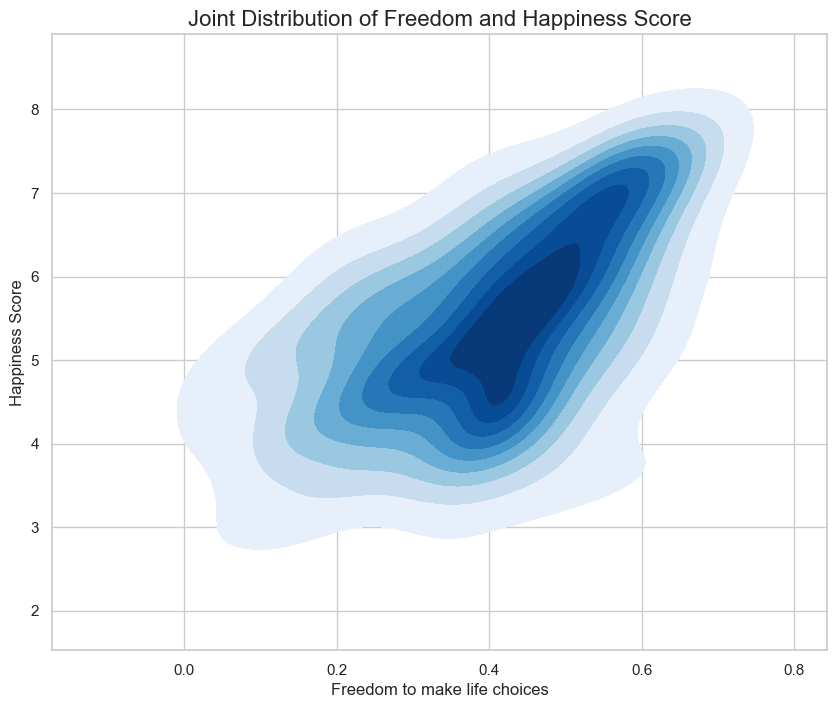

In [11]:
plt.figure(figsize=(10, 8))

sns.kdeplot(data=df, x='Freedom to make life choices', y='Happiness Score', fill=True, cmap="Blues", thresh=0.05, levels=10)

plt.title('Joint Distribution of Freedom and Happiness Score', fontsize=16)
plt.xlabel('Freedom to make life choices')
plt.ylabel('Happiness Score')
plt.show()

## Observations & Insights:
The contour plot reveals a prominent, dense cluster in the upper right quadrant. This indicates that a large concentration of countries enjoys both high levels of perceived freedom and high happiness scores. The shape of the density plot suggests that while low freedom is almost always tied to lower happiness, achieving a high degree of freedom is a core component (though not the only one) for a nation to reach the highest tiers of happiness.

## Q6.
Plot a histogram with bin customization for Generosity scores across all countries.
Overlay a KDE curve. Identify the skewness and describe what it implies about global generosity.

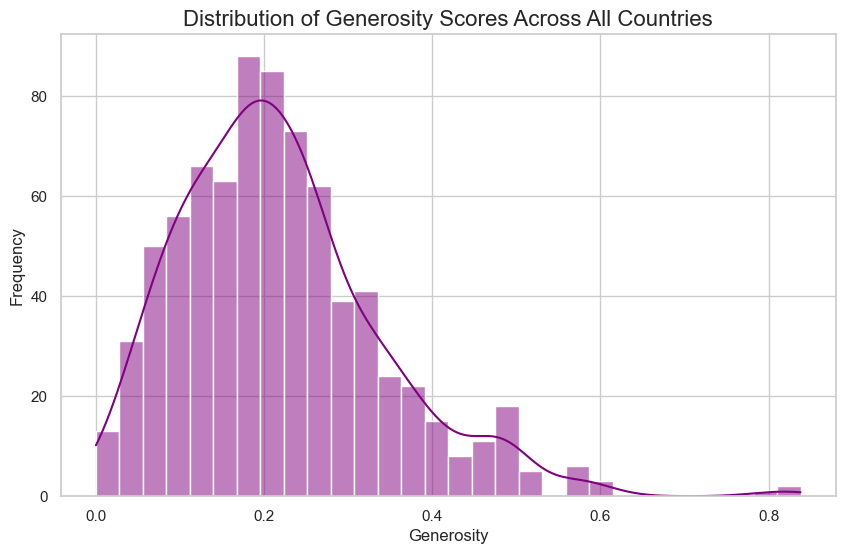

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='Generosity', bins=30, kde=True, color='purple')

plt.title('Distribution of Generosity Scores Across All Countries', fontsize=16)
plt.xlabel('Generosity')
plt.ylabel('Frequency')
plt.show()

## Observations & Insights:
The generosity distribution is heavily right-skewed. The KDE curve shows a massive peak at the lower end of the scale, meaning most countries report relatively low levels of generosity based on the survey's metrics. The long tail extending to the right represents a handful of outlier countries that score exceptionally high in charitable giving and generosity.

## Q7.
Create a 2×2 subplot grid showing:
(a) Line plot of GDP trend
(b) Scatter plot of social support vs. happiness
(c) Boxplot of generosity by region
(d) Heatmap of correlations

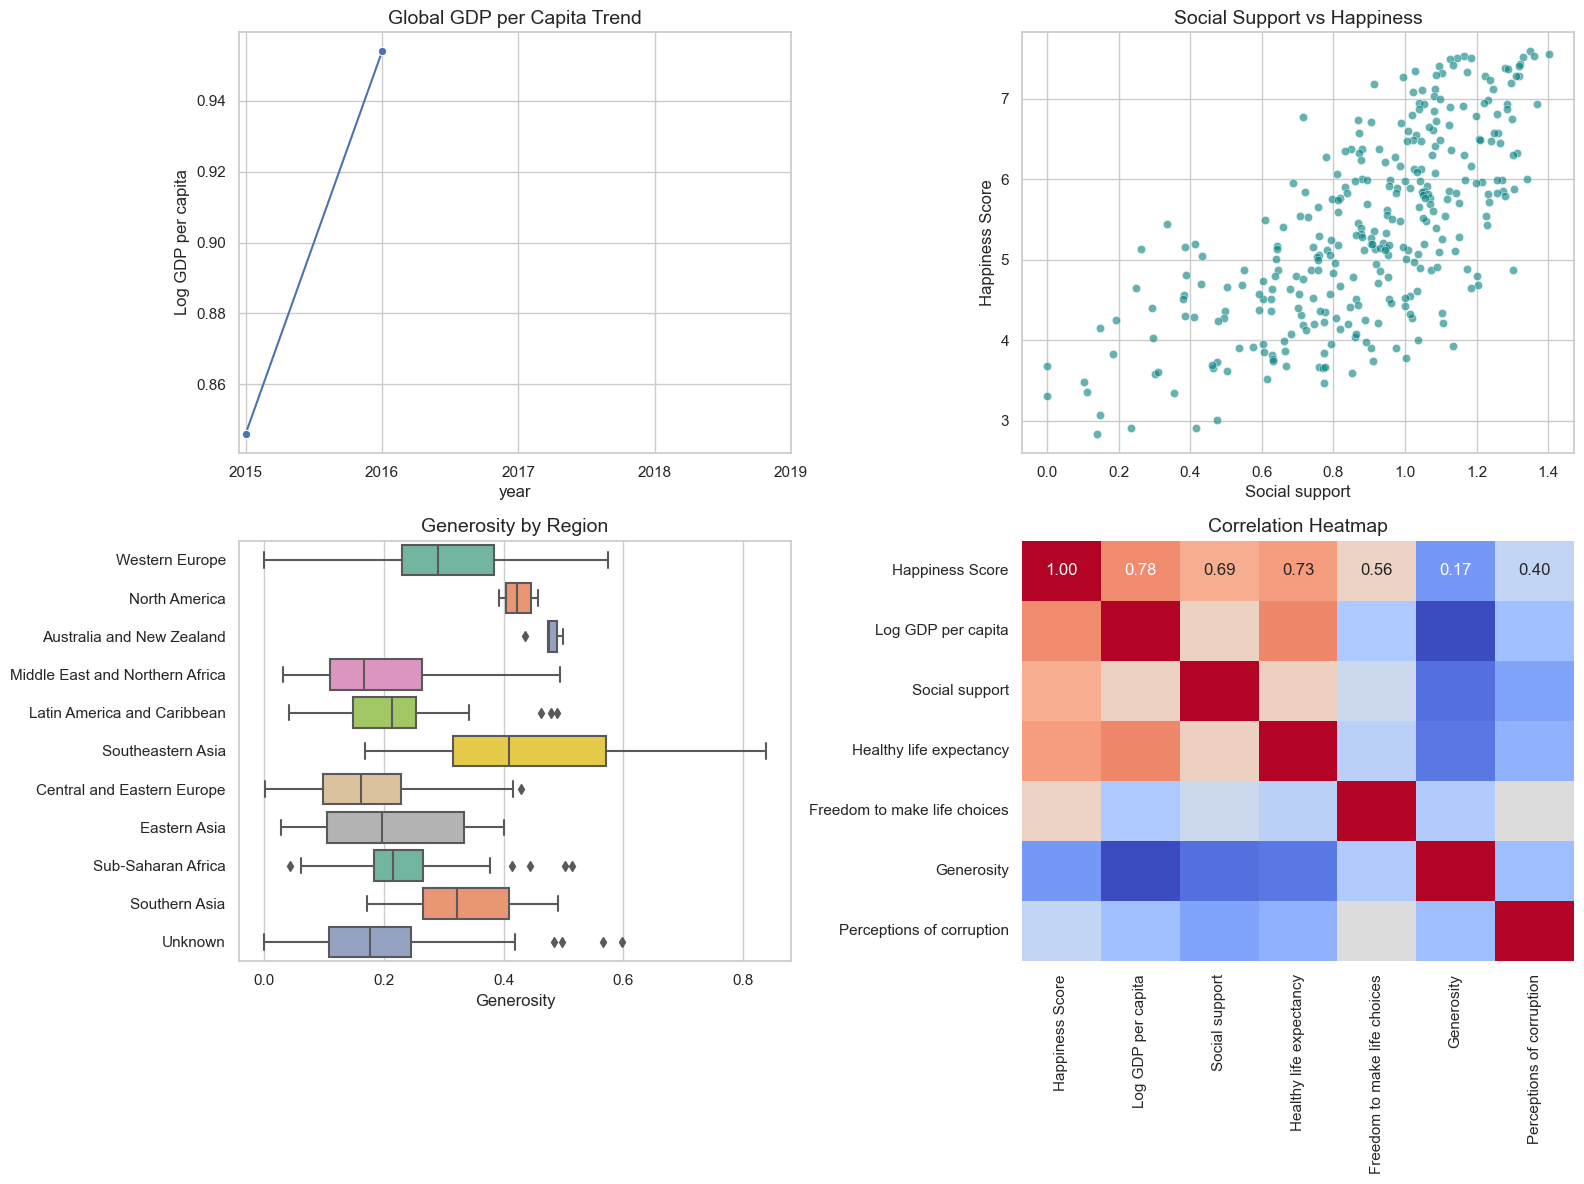

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Line plot of GDP trend
sns.lineplot(data=df.groupby('year')['Log GDP per capita'].mean().reset_index(), x='year', y='Log GDP per capita', ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Global GDP per Capita Trend', fontsize=14)
axes[0, 0].set_xticks(df['year'].unique())

# (b) Scatter of social support vs happiness
sns.scatterplot(data=df, x='Social support', y='Happiness Score', ax=axes[0, 1], alpha=0.6, color='teal')
axes[0, 1].set_title('Social Support vs Happiness', fontsize=14)

# (c) Boxplot of generosity by region
sns.boxplot(data=df, x='Generosity', y='Region', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Generosity by Region', fontsize=14)
axes[1, 0].set_ylabel('')

# (d) Heatmap of correlations
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['year'], errors='ignore')
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

## Observations & Insights:
GDP Trend: Shows the macro-economic trajectory across the years represented in the dataset.
Social Support: Exhibits a strong, almost exponential positive relationship with happiness. Lack of social support is devastating to national happiness.
Generosity by Region: Shows wide variances. Some regions have tight distributions, while others contain significant positive outliers.
Correlation Heatmap: Confirms that GDP, Social Support, and Healthy Life Expectancy are the strongest predictors of Happiness. Generosity and Perceptions of Corruption have much weaker linear relationships with the overall score.

## Q8.
Use Seaborn’s FacetGrid to create scatter plots of Health (Life Expectancy) vs. Happiness Score for each region in separate panels.
Compare inter-region patterns.

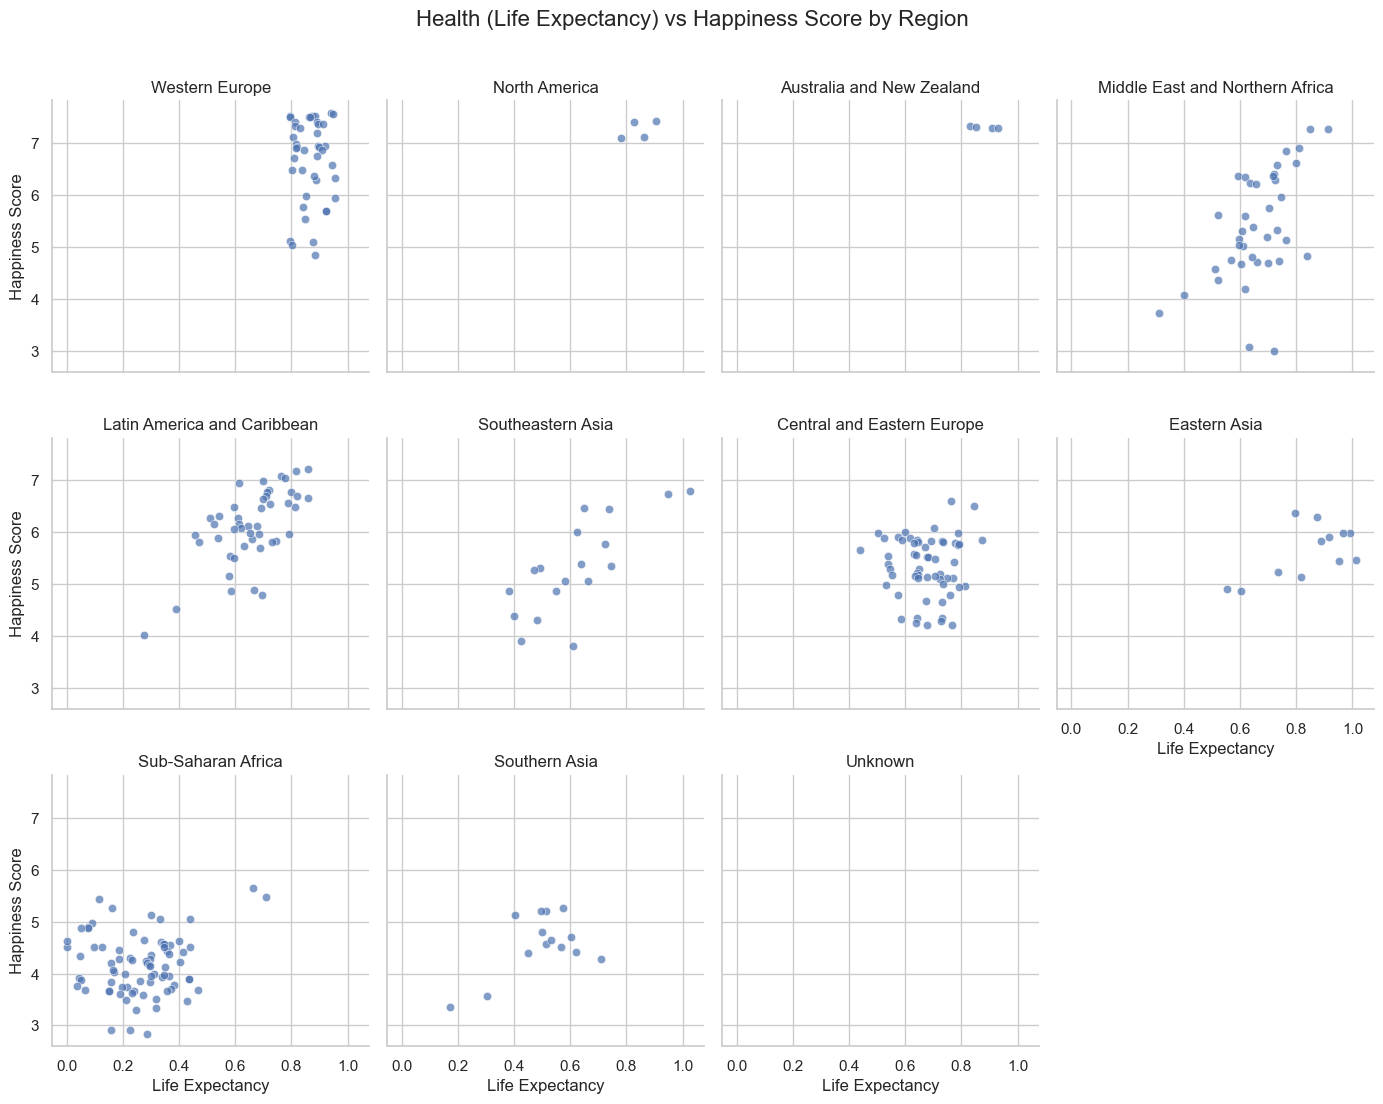

In [14]:
g = sns.FacetGrid(df, col="Region", col_wrap=4, height=3.5)
g.map_dataframe(sns.scatterplot, x="Healthy life expectancy", y="Happiness Score", alpha=0.7)
g.set_axis_labels("Life Expectancy", "Happiness Score")
g.set_titles(col_template="{col_name}")
g.fig.suptitle('Health (Life Expectancy) vs Happiness Score by Region', y=1.05, fontsize=16)
plt.show()

## Observations & Insights:
Breaking the data down by region reveals that the global linear trend doesn't perfectly apply everywhere. In highly developed regions (like Western Europe), points cluster tightly in the top right. In regions like Sub-Saharan Africa, life expectancy is generally much lower, and the spread of happiness is wider. This suggests a hierarchical nature to these metrics: achieving a baseline of health is necessary, but once achieved, other factors drive the variation in happiness.

## Q9.
Create a Seaborn clustermap (hierarchical heatmap) of the full correlation matrix.
Identify clusters of countries with similar happiness profiles.

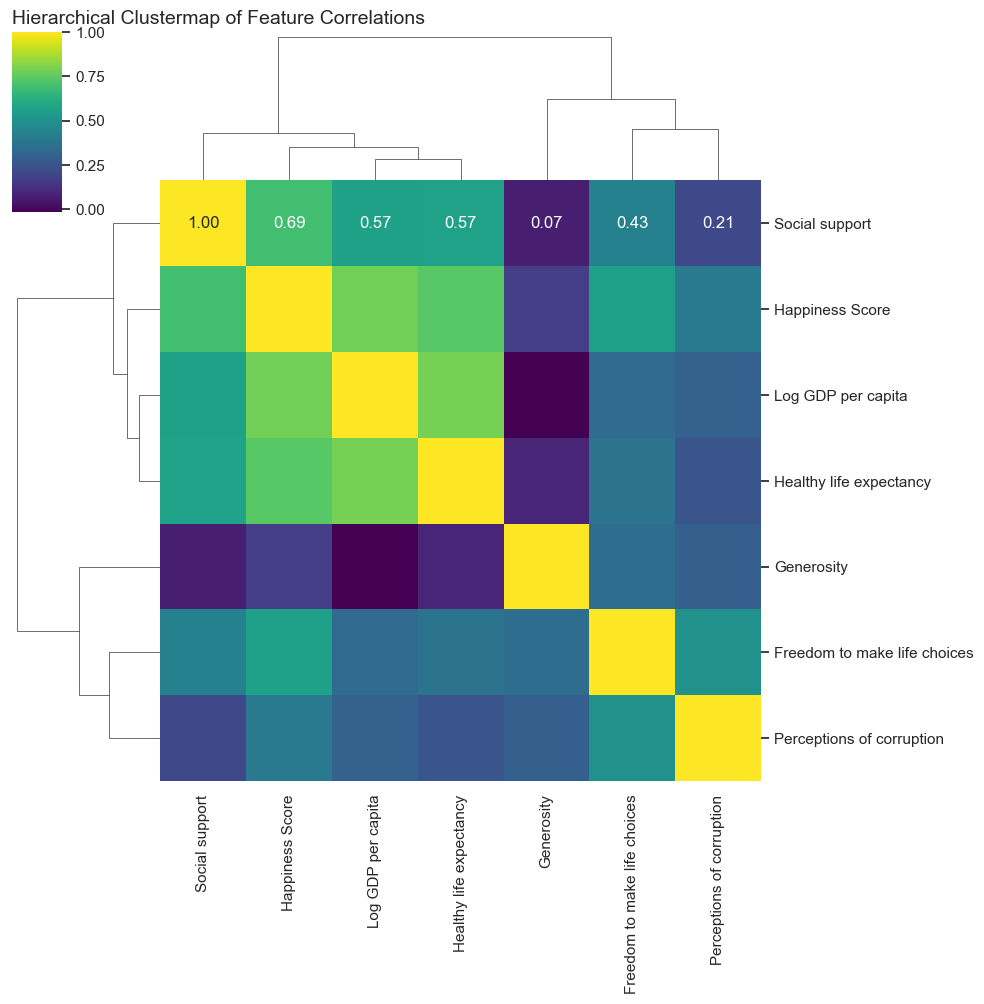

In [15]:
# Calculate correlation matrix of numeric features
corr_matrix = numeric_df.corr()

# Plot clustermap
sns.clustermap(corr_matrix, annot=True, fmt=".2f", cmap='viridis', figsize=(10, 10), method='ward')
plt.title('Hierarchical Clustermap of Feature Correlations', loc='left', fontsize=14)
plt.show()

## Observations & Insights:
The clustermap groups the variables based on their relationships. Noticeably, Happiness Score, Log GDP per capita, Social support, and Healthy life expectancy form a distinct, tight cluster. This reinforces the finding that economic output, community support, and health are deeply intertwined and form the core foundation of a nation's happiness. Generosity and Corruption cluster separately, acting as secondary, less highly correlated metrics.

## Q10.
Build an annotated Seaborn heatmap of average happiness component scores by region (rows) and year (columns).
Discuss temporal and regional trends.

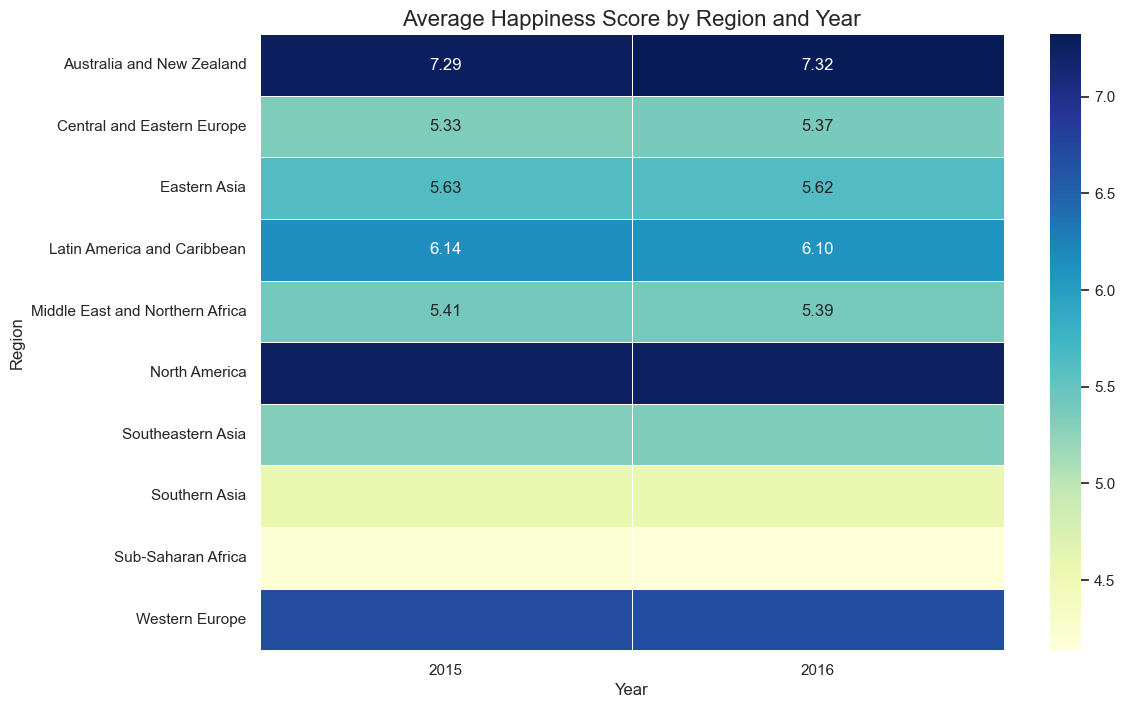

In [16]:
plt.figure(figsize=(12, 8))

# Create pivot table for the heatmap
pivot_df = df.pivot_table(values='Happiness Score', index='Region', columns='year', aggfunc='mean')

# Plot heatmap
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=.5)

plt.title('Average Happiness Score by Region and Year', fontsize=16)
plt.ylabel('Region', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.show()

## Observations & Insights:
This heatmap effectively tracks regional stability over the 5-year span. Regions at the top (e.g., North America, Western Europe) maintain dark, stable colors, indicating sustained high happiness. Regions at the bottom (e.g., Sub-Saharan Africa) remain light. By looking across the rows chronologically, we can spot regions making incremental improvements or slight declines over the half-decade.